# Effects of perturbations on cytokines 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import scanpy as sc
import anndata
from scipy.cluster.hierarchy import fcluster
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15

import sys
sys.path.append('../3_DE_analysis/')
from DE_analysis_utils import *
import yaml
with open('../../metadata/figure_palettes.yaml', 'r') as f:
    palettes = yaml.safe_load(f)

/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/rzhu/miniconda3/envs/deseq/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Load DE data, filter genes and perturbations, extract cytokine effects

In [5]:
import gc

datadir = '../../../../3_expts/processed_data/CD4i_final/'
h5ad_path = datadir + '/DE_results_all_confounders/CD4i_final.merged_DE_results_corrected.h5ad'

# --- Open backed to keep layers on disk ---
adata_de = sc.read_h5ad(h5ad_path, backed='r')
obs_df = adata_de.obs.to_df() if hasattr(adata_de.obs, 'to_df') else adata_de.obs.copy()
var_df = adata_de.var.copy()

# --- Filter lowly expressed genes (read baseMean for deduplicated rows only) ---
dedup_idx = sorted(np.where(~obs_df[['culture_condition', 'chunk']].duplicated())[0])
baseMean_dedup = pd.DataFrame(
    np.array(adata_de.layers['baseMean'][dedup_idx, :]),
    columns=var_df.index
)
baseMean_dedup['culture_condition'] = obs_df.iloc[dedup_idx]['culture_condition'].values

gs_mask = pd.Series(True, index=var_df.index)
for cond in ['Rest', 'Stim8hr', 'Stim48hr']:
    mean_bm = baseMean_dedup[baseMean_dedup['culture_condition'] == cond].drop('culture_condition', axis=1).mean(0).fillna(0)
    gs_mask &= (mean_bm > 0.1)
del baseMean_dedup
print(f"Filtered {sum(~gs_mask)} lowly expressed genes")

# --- Apply target contrast corrections ---
if 'target_contrast_corrected' in obs_df.columns:
    name_corr = dict(zip(obs_df['target_contrast_gene_name'], obs_df['target_contrast_gene_name_corrected']))
    tc_corr = dict(zip(obs_df['target_contrast'], obs_df['target_contrast_corrected']))
else:
    obs_corr = anndata.experimental.read_lazy(h5ad_path).obs.to_dataframe()
    name_corr = dict(zip(obs_corr['target_contrast_gene_name'], obs_corr['target_contrast_gene_name_corrected']))
    tc_corr = dict(zip(obs_corr['target_contrast'], obs_corr['target_contrast_corrected']))
    del obs_corr

obs_df['target_contrast_gene_name'] = obs_df['target_contrast_gene_name'].map(name_corr)
obs_df['target_contrast'] = obs_df['target_contrast'].map(tc_corr)
obs_df = obs_df.dropna(subset=['target_contrast_gene_name'])

# --- Exclude perturbations with poor donor robustness ---
donor_robustness = pd.read_csv('../3_DE_analysis/results/DE_donor_robustness_correlation_summary.csv', index_col=0)
donor_corr = donor_robustness.pivot(index='target_name', values='donor_correlation_mean', columns='condition')
remove_perturbs = donor_corr[~(donor_corr.fillna(1) > 0.05).any(axis=1)].index.tolist()
obs_df = obs_df[~obs_df['target_contrast_gene_name'].isin(remove_perturbs)]

# --- Compute valid row/col indices for cytokine subset ---
immune_genes_df = pd.read_csv('../../metadata/immune_effector_genes.csv')
cytokines = [g for g in immune_genes_df[immune_genes_df['Category'] == 'Cytokine']['gene_name'] if g not in ['IL17F', 'IL6']]

gene_names = var_df['gene_name'].values
cytokine_col_idx = sorted([i for i, g in enumerate(gene_names) if g in cytokines and gs_mask.iloc[i]])
valid_row_idx = sorted(np.where(adata_de.obs_names.isin(obs_df.index))[0])

# --- Read only cytokine columns from each layer (minimal memory) ---
layers = {}
for layer_name in ['zscore', 'log_fc', 'baseMean', 'adj_p_value']:
    cols = []
    for ci in cytokine_col_idx:
        col_all = np.asarray(adata_de.layers[layer_name][:, ci])
        cols.append(col_all[valid_row_idx])
    layers[layer_name] = np.column_stack(cols)

# --- Build small in-memory AnnData for cytokines only ---
adata_cytokines = anndata.AnnData(
    X=layers['zscore'],
    obs=obs_df.loc[adata_de.obs_names[valid_row_idx]],
    var=var_df.iloc[cytokine_col_idx],
    layers=layers
)
adata_cytokines.var_names = adata_cytokines.var['gene_name'].values

# Close backed file and free memory
adata_de.file.close()
del adata_de; gc.collect()
print(f"Built cytokine AnnData: {adata_cytokines.shape}")

# --- Extract DE results into long DataFrame ---
cytokines_de_df = get_DE_results_long(adata_cytokines, effect_estimates=['zscore', 'log_fc', 'baseMean'])
del adata_cytokines; gc.collect()

cytokines_de_df['target_condition'] = cytokines_de_df['target_contrast_gene_name'].astype(str) + '_' + cytokines_de_df['culture_condition'].astype(str)
cytokines_de_df = cytokines_de_df[cytokines_de_df['gene_name'] != cytokines_de_df['target_contrast_gene_name']]

unique_regulators = cytokines_de_df[cytokines_de_df['adj_p_value'] < 0.01]['target_contrast_gene_name'].unique()
print(f"{len(cytokines)} cytokines, {len(unique_regulators)} significant regulators")

Filtered 3677 lowly expressed genes
Built cytokine AnnData: (33869, 30)
34 cytokines, 1784 significant regulators


Order cytokines regulators by hierarchical clustering

In [6]:
filtered_df = cytokines_de_df[cytokines_de_df['target_contrast_gene_name'].isin(unique_regulators)].copy()

# Show only significant effects
filtered_df.loc[~filtered_df['significant'], 'zscore'] = 0

# Create pivot tables per condition
pivot_dfs = {}
for cond in ['Rest', 'Stim8hr', 'Stim48hr']:
    pivot_dfs[cond] = filtered_df[filtered_df['culture_condition'] == cond].pivot(
        index='gene_name', columns='target_contrast_gene_name', values='zscore'
    ).fillna(0)

# Get clustered order from Stim8hr
g = sns.clustermap(pivot_dfs['Stim8hr'], xticklabels=False, yticklabels=True,
                   cmap=palettes['DE_effects_cmap'], figsize=(13, 4), method='ward')
unique_regulators_order = pivot_dfs['Stim8hr'].columns[g.dendrogram_col.reordered_ind].tolist()
all_genes_order = pivot_dfs['Stim8hr'].index[g.dendrogram_row.reordered_ind].tolist()
plt.close()

# Reindex to clustered order
for cond in pivot_dfs:
    pivot_dfs[cond] = pivot_dfs[cond].reindex(index=all_genes_order, columns=unique_regulators_order).fillna(0)

rest_pl_df, stim8hr_pl_df, stim48hr_pl_df = pivot_dfs['Rest'], pivot_dfs['Stim8hr'], pivot_dfs['Stim48hr']

Plot effects in Rest and Stim8hr

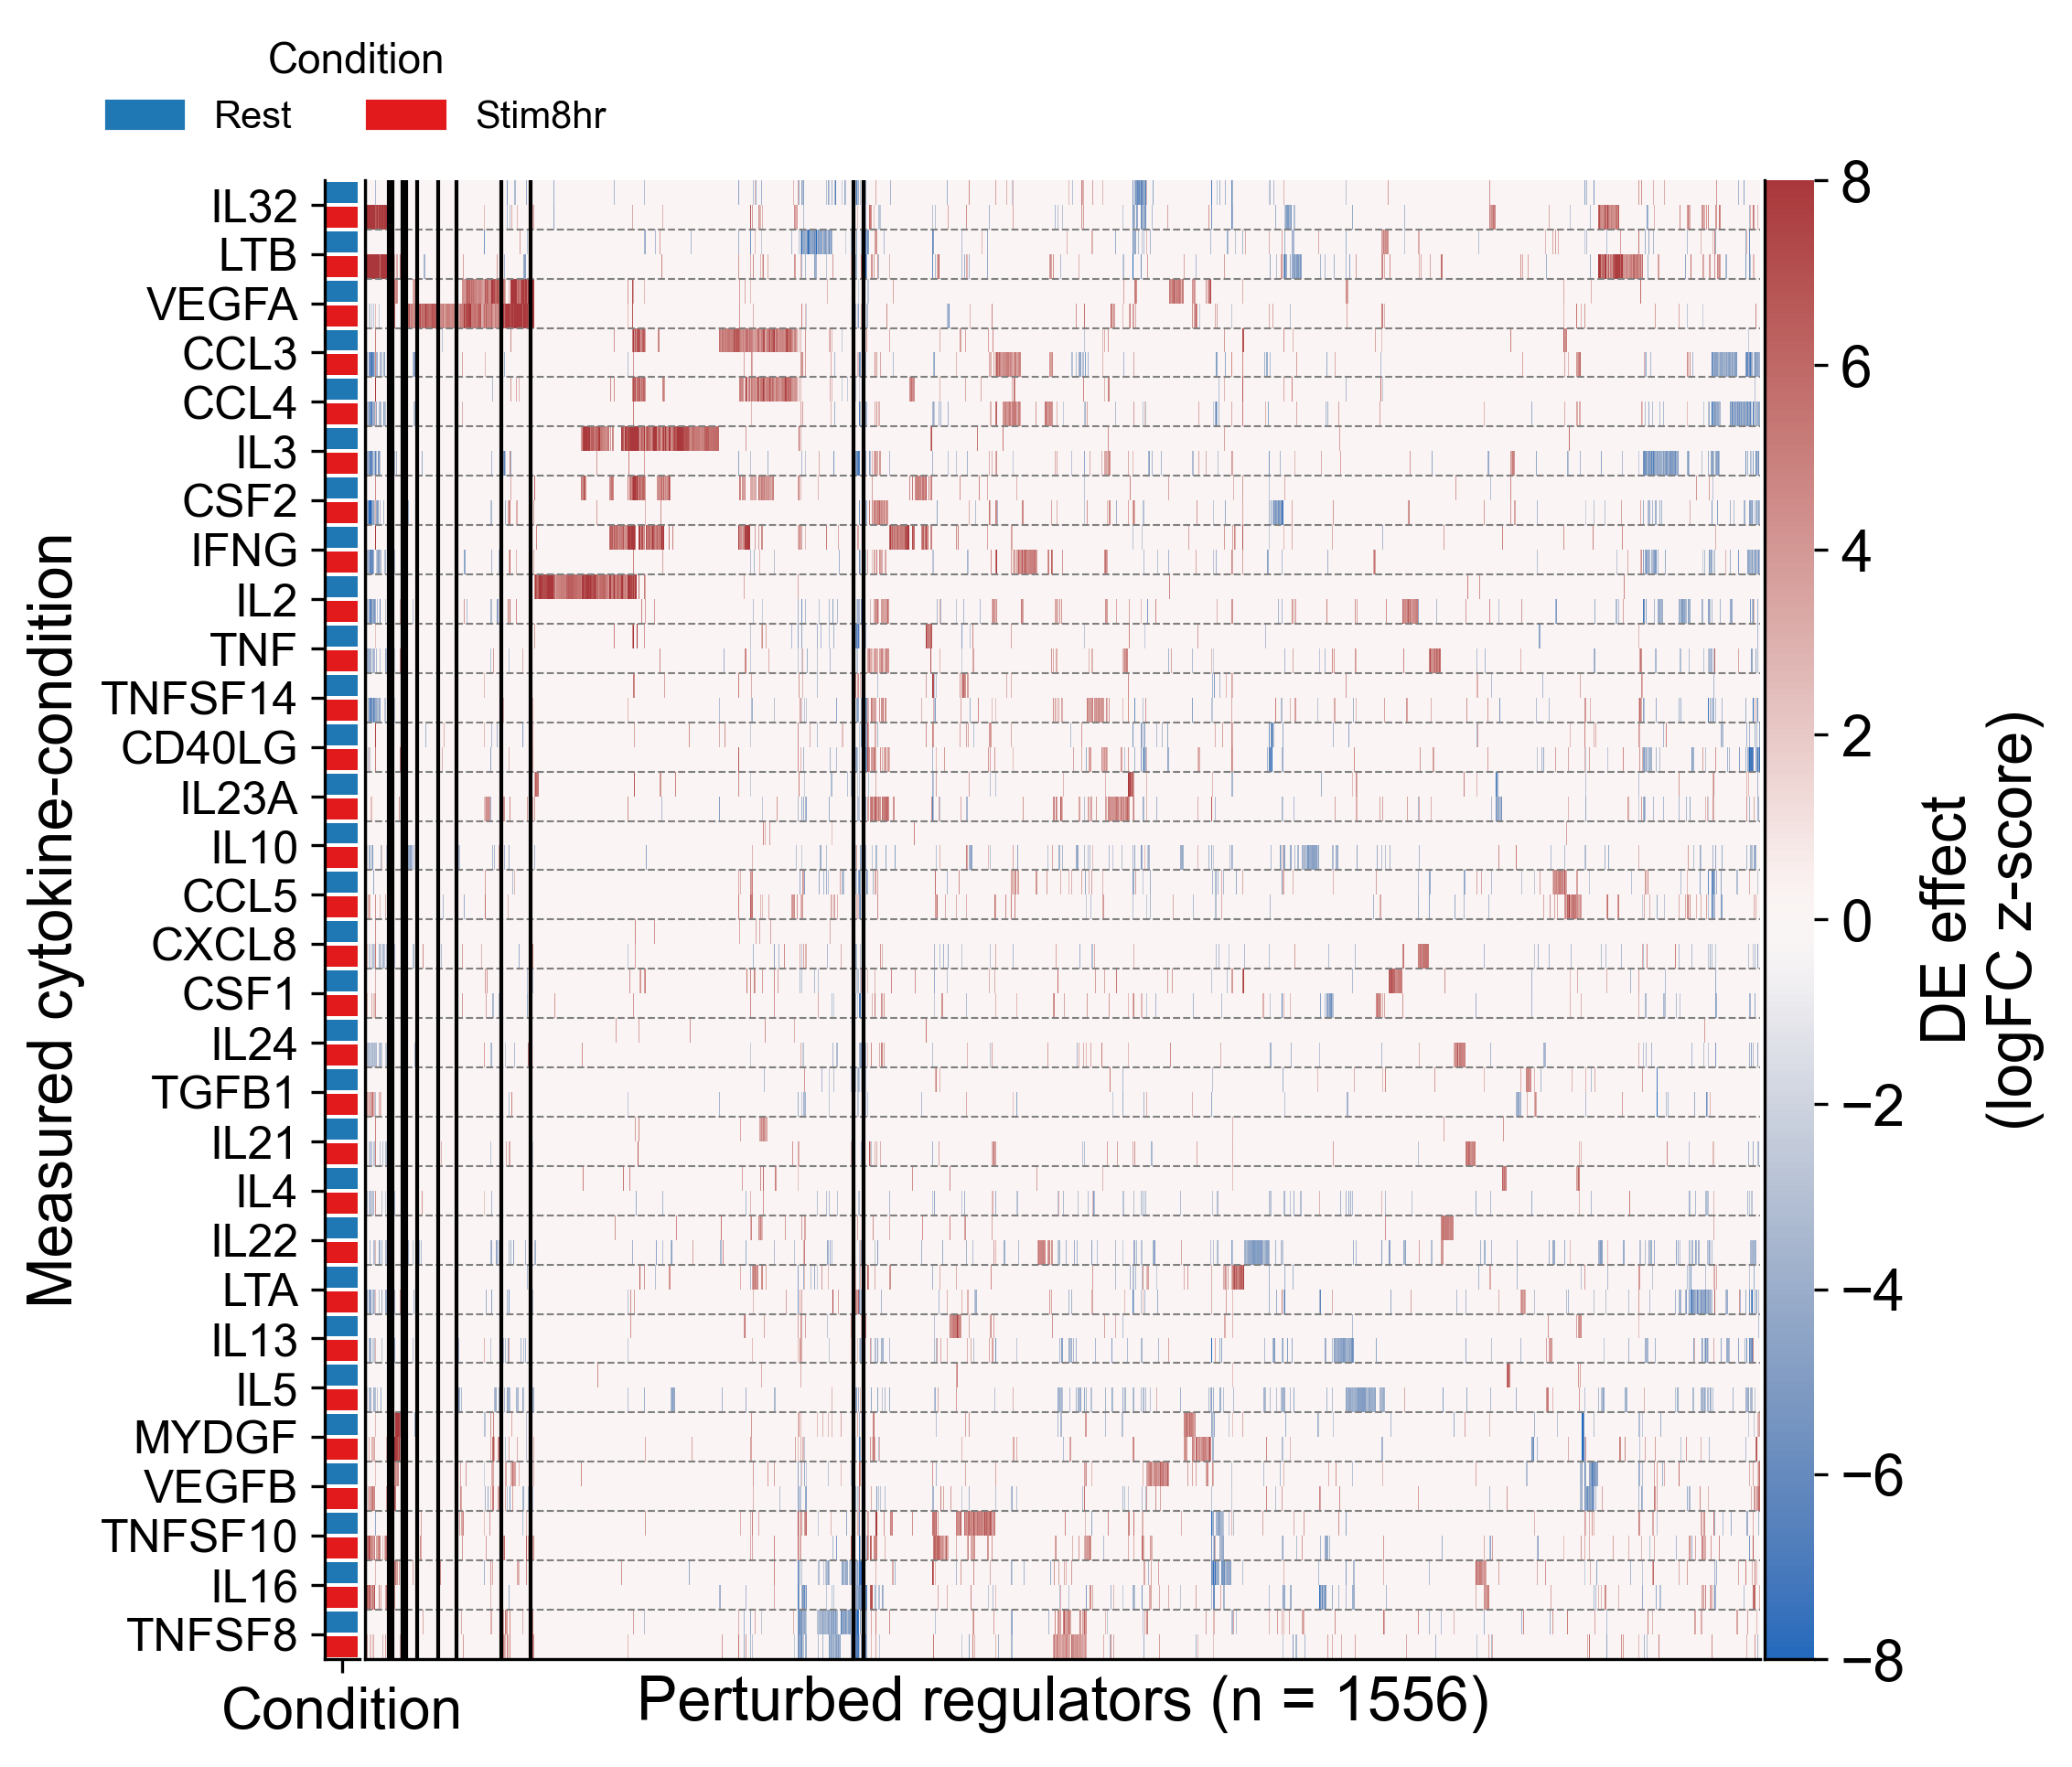

In [7]:
# Combine pivot tables vertically
rest_pl_df['condition'] = 'Rest'
stim8hr_pl_df['condition'] = 'Stim8hr'
stim48hr_pl_df['condition'] = 'Stim48hr'
combined_pl_df = pd.concat([rest_pl_df, stim8hr_pl_df, stim48hr_pl_df])
combined_pl_df = (combined_pl_df.reset_index()
    .sort_values(['gene_name', 'condition'],
                 key=lambda x: pd.Categorical(x, categories=all_genes_order + ['Rest', 'Stim8hr', 'Stim48hr'], ordered=True))
    .set_index(['gene_name', 'condition']))

plot_conditions = ['Rest', 'Stim8hr']

# Subset to Rest and Stim8hr
data_to_plot = combined_pl_df.loc[
    [(g, c) for g in all_genes_order for c in plot_conditions]
]
# Exclude regulators with no effect in conditions of interest
data_to_plot = data_to_plot.loc[:, data_to_plot.sum(0) != 0]

# Cluster columns
g = sns.clustermap(data_to_plot, row_cluster=False, method='ward')
pl_regulators_order = data_to_plot.columns[g.dendrogram_col.reordered_ind].tolist()
n_clusters = 15
col_clusters = fcluster(g.dendrogram_col.linkage, n_clusters, criterion='maxclust')[g.dendrogram_col.reordered_ind]
column_cluster_df = pd.DataFrame({'column_name': pl_regulators_order, 'cluster': col_clusters}).reset_index(drop=True)
plt.close()

# --- Plot ---
y_labelsize = 12
fig = plt.figure(figsize=(7, 7))
gs_fig = fig.add_gridspec(1, 3, width_ratios=[0.05, 2, 0.07], wspace=0.01)

# Row color annotation
ax_colors = fig.add_subplot(gs_fig[0, 0])
condition_mapping = {c: i for i, c in enumerate(plot_conditions)}
row_color_codes = [condition_mapping[c] for _ in all_genes_order for c in plot_conditions]
condition_colors = [palettes['culture_condition'][c] for c in plot_conditions]
cmap_cond = ListedColormap(condition_colors)

sns.heatmap(np.array(row_color_codes).reshape(-1, 1), cmap=cmap_cond, cbar=False,
            yticklabels=False, xticklabels=['Condition'],
            linewidths=0.5, linecolor='white', ax=ax_colors)

y_tick_locs = [i * 2 + 1 for i in range(len(all_genes_order))]
ax_colors.set_yticks(y_tick_locs)
ax_colors.set_yticklabels(all_genes_order, fontsize=y_labelsize)
ax_colors.set_ylabel('Measured cytokine-condition')

legend_patches = [mpatches.Patch(color=palettes['culture_condition'][c], label=c) for c in plot_conditions]
ax_colors.legend(handles=legend_patches, title='Condition', frameon=False, ncols=2,
                 bbox_to_anchor=(0.9, 1.02), loc='lower center', fontsize=10, title_fontsize=11, borderaxespad=0.)

# Heatmap
ax1 = fig.add_subplot(gs_fig[0, 1])
cbar_ax = fig.add_subplot(gs_fig[0, 2])

sns.heatmap(data_to_plot[pl_regulators_order], center=0, cmap=palettes['DE_effects_cmap'],
            vmax=8, vmin=-8, cbar=True, cbar_ax=cbar_ax,
            cbar_kws={'label': 'DE effect\n(logFC z-score)', 'shrink': 0.85},
            xticklabels=False, yticklabels=False, ax=ax1, rasterized=True)
ax1.set_xlabel(f'Perturbed regulators (n = {data_to_plot.shape[1]})')
ax1.set_ylabel('')

# Horizontal lines between cytokines
for i in range(1, len(all_genes_order)):
    ax1.axhline(y=i * 2, color='gray', linestyle='--', linewidth=0.5)

# Vertical lines at specified positions
vline_positions = [0, 27, 31, 42, 46, 58, 82, 102, 152, 185, 545, 556]
for pos in vline_positions:
    ax1.axvline(x=pos, color='black', linewidth=1)

sns.despine()
fig.tight_layout()

In [8]:
print(f"Number of regulators plotted: {len(pl_regulators_order)}")
print("X-axis regulator order (left to right):")
pl_regulators_order

Number of regulators plotted: 1556
X-axis regulator order (left to right):


['PLCG1',
 'CD247',
 'BCAT2',
 'FITM2',
 'CD3E',
 'LCP2',
 'CD3G',
 'ZAP70',
 'LAT',
 'VAV1',
 'CD3D',
 'ATP2A2',
 'ARHGAP27',
 'PLAT',
 'FZD6',
 'ITK',
 'TMX1',
 'PGGT1B',
 'MBD5',
 'ZBED3',
 'PLEK2',
 'LRIG1',
 'SLC3A2',
 'CALCOCO2',
 'LRBA',
 'SKIC2',
 'PTPRC',
 'LCK',
 'SEC61B',
 'SLC35B1',
 'MPI',
 'SEL1L',
 'XRRA1',
 'DOLPP1',
 'MYO9A',
 'SEC63',
 'ZNF554',
 'DNAJB9',
 'PDIA6',
 'UBA5',
 'ACAD11',
 'DDRGK1',
 'UFM1',
 'CDS2',
 'TMED2',
 'CDIPT',
 'MRPL10',
 'NPC2',
 'ISCA2',
 'TP53RK',
 'SP1',
 'ALG2',
 'GLS2',
 'MRPS17',
 'MRPL11',
 'SSBP1',
 'GFER',
 'TIMM50',
 'MRPL14',
 'ENTR1',
 'LETM1',
 'MTHFD1L',
 'DLD',
 'NUDT5',
 'DNAJA3',
 'APEX1',
 'EPHB4',
 'PDAP1',
 'EGLN1',
 'IBA57',
 'GINM1',
 'FPGS',
 'EIF2B1',
 'SLC25A3',
 'HARS2',
 'OSGEP',
 'SHMT2',
 'TRMT6',
 'ELK1',
 'LTA',
 'GRIN3A',
 'MMGT1',
 'GADD45GIP1',
 'NDUFA8',
 'NDUFS8',
 'MRPS23',
 'PPIL1',
 'TENT5C',
 'SAMD1',
 'MRPS35',
 'ATP5F1B',
 'FUNDC2',
 'NADSYN1',
 'TPK1',
 'MRPL16',
 'SUCLG1',
 'MRPS15',
 'KGD4',
 'ATP5P

In [9]:
# Load guide condordance info
de_guide_stats = pd.read_csv('../../metadata/DE_by_guide.correlation_results.csv', index_col=0)

In [10]:
de_guide_stats

,target,correlation_signif,correlation_signif_pval,correlation_all,correlation_all_pval,n_signif_union,frac_sign_agreement_signif_union,n_signif_1,n_signif_2,guide_id_1,guide_id_2,culture_condition,n_signif_ontarget
0,A1BG,-1.000000,1.000000,-0.016747,7.229013e-02,2,0.000000,1,1,A1BG-1,A1BG-2,Rest,0
1,PIK3R2,0.745314,0.464599,0.107465,6.153747e-31,3,0.666667,2,2,PIK3R2-1,PIK3R2-2,Rest,2
2,PIK3C2A,0.776285,0.434204,0.032724,4.437638e-04,3,0.333333,1,2,PIK3C2A-1,PIK3C2A-2,Rest,1
3,PIK3CA,0.718541,0.281459,-0.036052,1.088217e-04,4,0.750000,1,4,PIK3CA-1,PIK3CA-2,Rest,2
4,PIK3CB,0.969089,0.158701,0.042223,5.815267e-06,3,1.000000,2,2,PIK3CB-1,PIK3CB-2,Rest,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26491,FAM126A,1.000000,1.000000,0.062255,2.275848e-11,2,0.500000,2,1,FAM126A-1,FAM126A-2,Stim48hr,2
26492,FLT3LG,0.867498,0.331453,-0.009935,2.863502e-01,3,0.666667,3,1,FLT3LG-1,FLT3LG-2,Stim48hr,2
26493,KIT,NaN,NaN,0.106126,3.296337e-30,1,0.000000,0,1,KIT-1,KIT-2,Stim48hr,0
26494,ITGAL,0.745154,0.054592,0.060295,9.410406e-11,7,0.571429,2,7,ITGAL-1,ITGAL-2,Stim48hr,2


In [16]:
import gseapy as gp

# Background = all regulators plotted in the heatmap
background = data_to_plot.columns.tolist()
regulator_pos = {g: i for i, g in enumerate(pl_regulators_order)}

# Mean guide correlation per target gene
guide_corr = de_guide_stats.groupby('target')['correlation_all'].mean()

# Run enrichment on each column cluster (GO only)
enrichment_results = {}
for cl_id in sorted(column_cluster_df['cluster'].unique()):
    genes = column_cluster_df[column_cluster_df['cluster'] == cl_id]['column_name'].tolist()
    if len(genes) < 3:
        continue
    try:
        enr = gp.enrich(
            gene_list=genes,
            gene_sets=['GO_Biological_Process_2023'],
            background=background,
            outdir=None,
            no_plot=True,
            verbose=False
        )
        sig = enr.results[enr.results['Adjusted P-value'] < 0.05].copy()
        if len(sig) > 0:
            sig['cluster'] = cl_id
            sig['cluster_size'] = len(genes)
            enrichment_results[cl_id] = sig
    except Exception as e:
        print(f"Cluster {cl_id} ({len(genes)} genes): enrichment failed - {e}")

if enrichment_results:
    enrichment_df = pd.concat(enrichment_results.values(), ignore_index=True)
    enrichment_df = enrichment_df.sort_values(['cluster', 'Adjusted P-value'])
    
    print(f"Background size: {len(background)} regulators")
    print(f"Clusters with significant GO enrichment: {len(enrichment_results)} / {column_cluster_df['cluster'].nunique()}\n")
    for cl_id, grp in enrichment_df.groupby('cluster'):
        print(f"--- Cluster {cl_id} ({grp['cluster_size'].iloc[0]} genes)")
        for rank, (_, row) in enumerate(grp.head(3).iterrows(), 1):
            overlap_genes = row['Genes'].split(';')
            print(f"    [{rank}] {row['Term'][:90]}  (p_adj={row['Adjusted P-value']:.2e})")
            for g in sorted(overlap_genes, key=lambda x: regulator_pos.get(x, -1)):
                corr_val = guide_corr.get(g, np.nan)
                corr_str = f"{corr_val:.3f}" if not np.isnan(corr_val) else "N/A"
                print(f"        {g}: position {regulator_pos.get(g, 'N/A')}, guide_corr={corr_str}")
        print()
else:
    print("No clusters showed significant GO enrichment (adj. p < 0.05)")

Background size: 1556 regulators
Clusters with significant GO enrichment: 7 / 15

--- Cluster 1 (28 genes)
    [1] T Cell Receptor Signaling Pathway (GO:0050852)  (p_adj=9.39e-10)
        PLCG1: position 0, guide_corr=0.441
        CD247: position 1, guide_corr=0.314
        CD3E: position 4, guide_corr=N/A
        LCP2: position 5, guide_corr=N/A
        CD3G: position 6, guide_corr=0.444
        ZAP70: position 7, guide_corr=N/A
        CD3D: position 10, guide_corr=0.283
        ITK: position 15, guide_corr=0.298
        PTPRC: position 26, guide_corr=N/A
        LCK: position 27, guide_corr=N/A
    [2] Antigen Receptor-Mediated Signaling Pathway (GO:0050851)  (p_adj=1.14e-09)
        PLCG1: position 0, guide_corr=0.441
        CD247: position 1, guide_corr=0.314
        CD3E: position 4, guide_corr=N/A
        LCP2: position 5, guide_corr=N/A
        CD3G: position 6, guide_corr=0.444
        ZAP70: position 7, guide_corr=N/A
        CD3D: position 10, guide_corr=0.283
        ITK:

In [26]:
import gseapy as gp
from concurrent.futures import ThreadPoolExecutor, as_completed

# Sliding window enrichment along pl_regulators_order
background = data_to_plot.columns.tolist()
guide_corr = de_guide_stats.groupby('target')['correlation_all'].mean()
regulator_pos = {g: i for i, g in enumerate(pl_regulators_order)}

gene_sets = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'Reactome_2022',
    'WikiPathway_2023_Human',
    'MSigDB_Hallmark_2020',
]

window_sizes = [120]
step = 10

# Build all window tasks
tasks = []
for ws in window_sizes:
    for start in range(0, len(pl_regulators_order) - ws + 1, step):
        genes = pl_regulators_order[start:start + ws]
        tasks.append((ws, start, start + ws - 1, genes))

def run_enrichment(task):
    ws, start, end, genes = task
    genes_set = set(genes)
    try:
        enr = gp.enrich(
            gene_list=genes,
            gene_sets=gene_sets,
            background=background,
            outdir=None,
            no_plot=True,
            verbose=False
        )
        sig = enr.results[enr.results['Adjusted P-value'] < 0.05].copy()
        if len(sig) > 0:
            # Keep top 3 terms per database
            sig = sig.sort_values('Adjusted P-value').groupby('Gene_set').head(3)
            sig['window_size'] = ws
            sig['window_start'] = start
            sig['window_end'] = end
            # Filter overlap genes to only those in the window
            def gene_info(genes_str):
                genes_list = [g for g in genes_str.split(';') if g in genes_set]
                filtered_str = ';'.join(genes_list)
                pos_str = ';'.join(f"{g}:{regulator_pos.get(g, 'NA')}" for g in genes_list)
                corr_str = ';'.join(f"{g}:{guide_corr.get(g, np.nan):.3f}" if not np.isnan(guide_corr.get(g, np.nan)) else f"{g}:NA" for g in genes_list)
                return pd.Series([filtered_str, pos_str, corr_str])
            sig[['Genes', 'Gene_positions', 'Gene_guide_corr']] = sig['Genes'].apply(gene_info)
            return sig
    except:
        pass
    return None

print(f"Running {len(tasks)} windows across {len(window_sizes)} sizes, {len(gene_sets)} gene set libraries...")
all_results = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(run_enrichment, t): t for t in tasks}
    for fut in as_completed(futures):
        res = fut.result()
        if res is not None:
            all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
print(f"Done. {len(results_df)} significant terms found across all windows.\n")

if len(results_df) > 0:
    # Drop legacy gseapy columns
    results_df = results_df.drop(columns=['Old P-value', 'Old Adjusted P-value'], errors='ignore')
    results_df = results_df.sort_values(['window_size', 'window_start', 'Adjusted P-value'])
    outpath = 'results/cytokine_regulators_sliding_window_enrichment.csv'
    results_df.to_csv(outpath, index=False)
    print(f"Saved to {outpath}")

    # Summary by gene set library
    print(f"\nTerms per library:")
    print(results_df['Gene_set'].value_counts().to_string())

    # Show top 10 overall
    print(f"\nTop 10 terms overall (by p_adj):")
    for _, r in results_df.nsmallest(10, 'Adjusted P-value').iterrows():
        print(f"  [{r['Gene_set']}] window {r['window_start']}-{r['window_end']} (size {r['window_size']}): "
              f"{r['Term'][:70]}  (p_adj={r['Adjusted P-value']:.2e})")
        for g in r['Genes'].split(';'):
            corr_val = guide_corr.get(g, np.nan)
            corr_str = f"{corr_val:.3f}" if not np.isnan(corr_val) else "NA"
            print(f"    {g}: pos={regulator_pos.get(g, 'NA')}, guide_corr={corr_str}")

Running 144 windows across 1 sizes, 5 gene set libraries...
Done. 354 significant terms found across all windows.

Saved to results/cytokine_regulators_sliding_window_enrichment.csv

Terms per library:
Gene_set
GO_Biological_Process_2023    145
Reactome_2022                 100
KEGG_2021_Human                71
WikiPathway_2023_Human         27
MSigDB_Hallmark_2020           11

Top 10 terms overall (by p_adj):
  [Reactome_2022] window 70-189 (size 120): tRNA Processing R-HSA-72306  (p_adj=6.11e-16)
    PUS3: pos=127, guide_corr=0.094
    METTL1: pos=170, guide_corr=0.272
    TSEN15: pos=124, guide_corr=NA
    DDX1: pos=154, guide_corr=0.301
    ELAC2: pos=151, guide_corr=NA
    URM1: pos=176, guide_corr=0.193
    TSEN2: pos=155, guide_corr=0.309
    LAGE3: pos=178, guide_corr=0.139
    OSGEP: pos=75, guide_corr=NA
    ADAT3: pos=172, guide_corr=0.223
    THG1L: pos=135, guide_corr=NA
    ADAT2: pos=168, guide_corr=0.137
    CTU2: pos=184, guide_corr=0.199
    CTU1: pos=182, guide_corr

In [ ]:
{'Glycolysis': [1434, 1547],
 'mRNA processing': [1037, 1128],
 'Ragulator-Rag': [876, 953],
 'Mediator-SAGA': [514, 556],
 'Elongator': [152, 185],
 'Mitochrondrial functions': [46, 102],
 'TCR activation': [0, 27]}

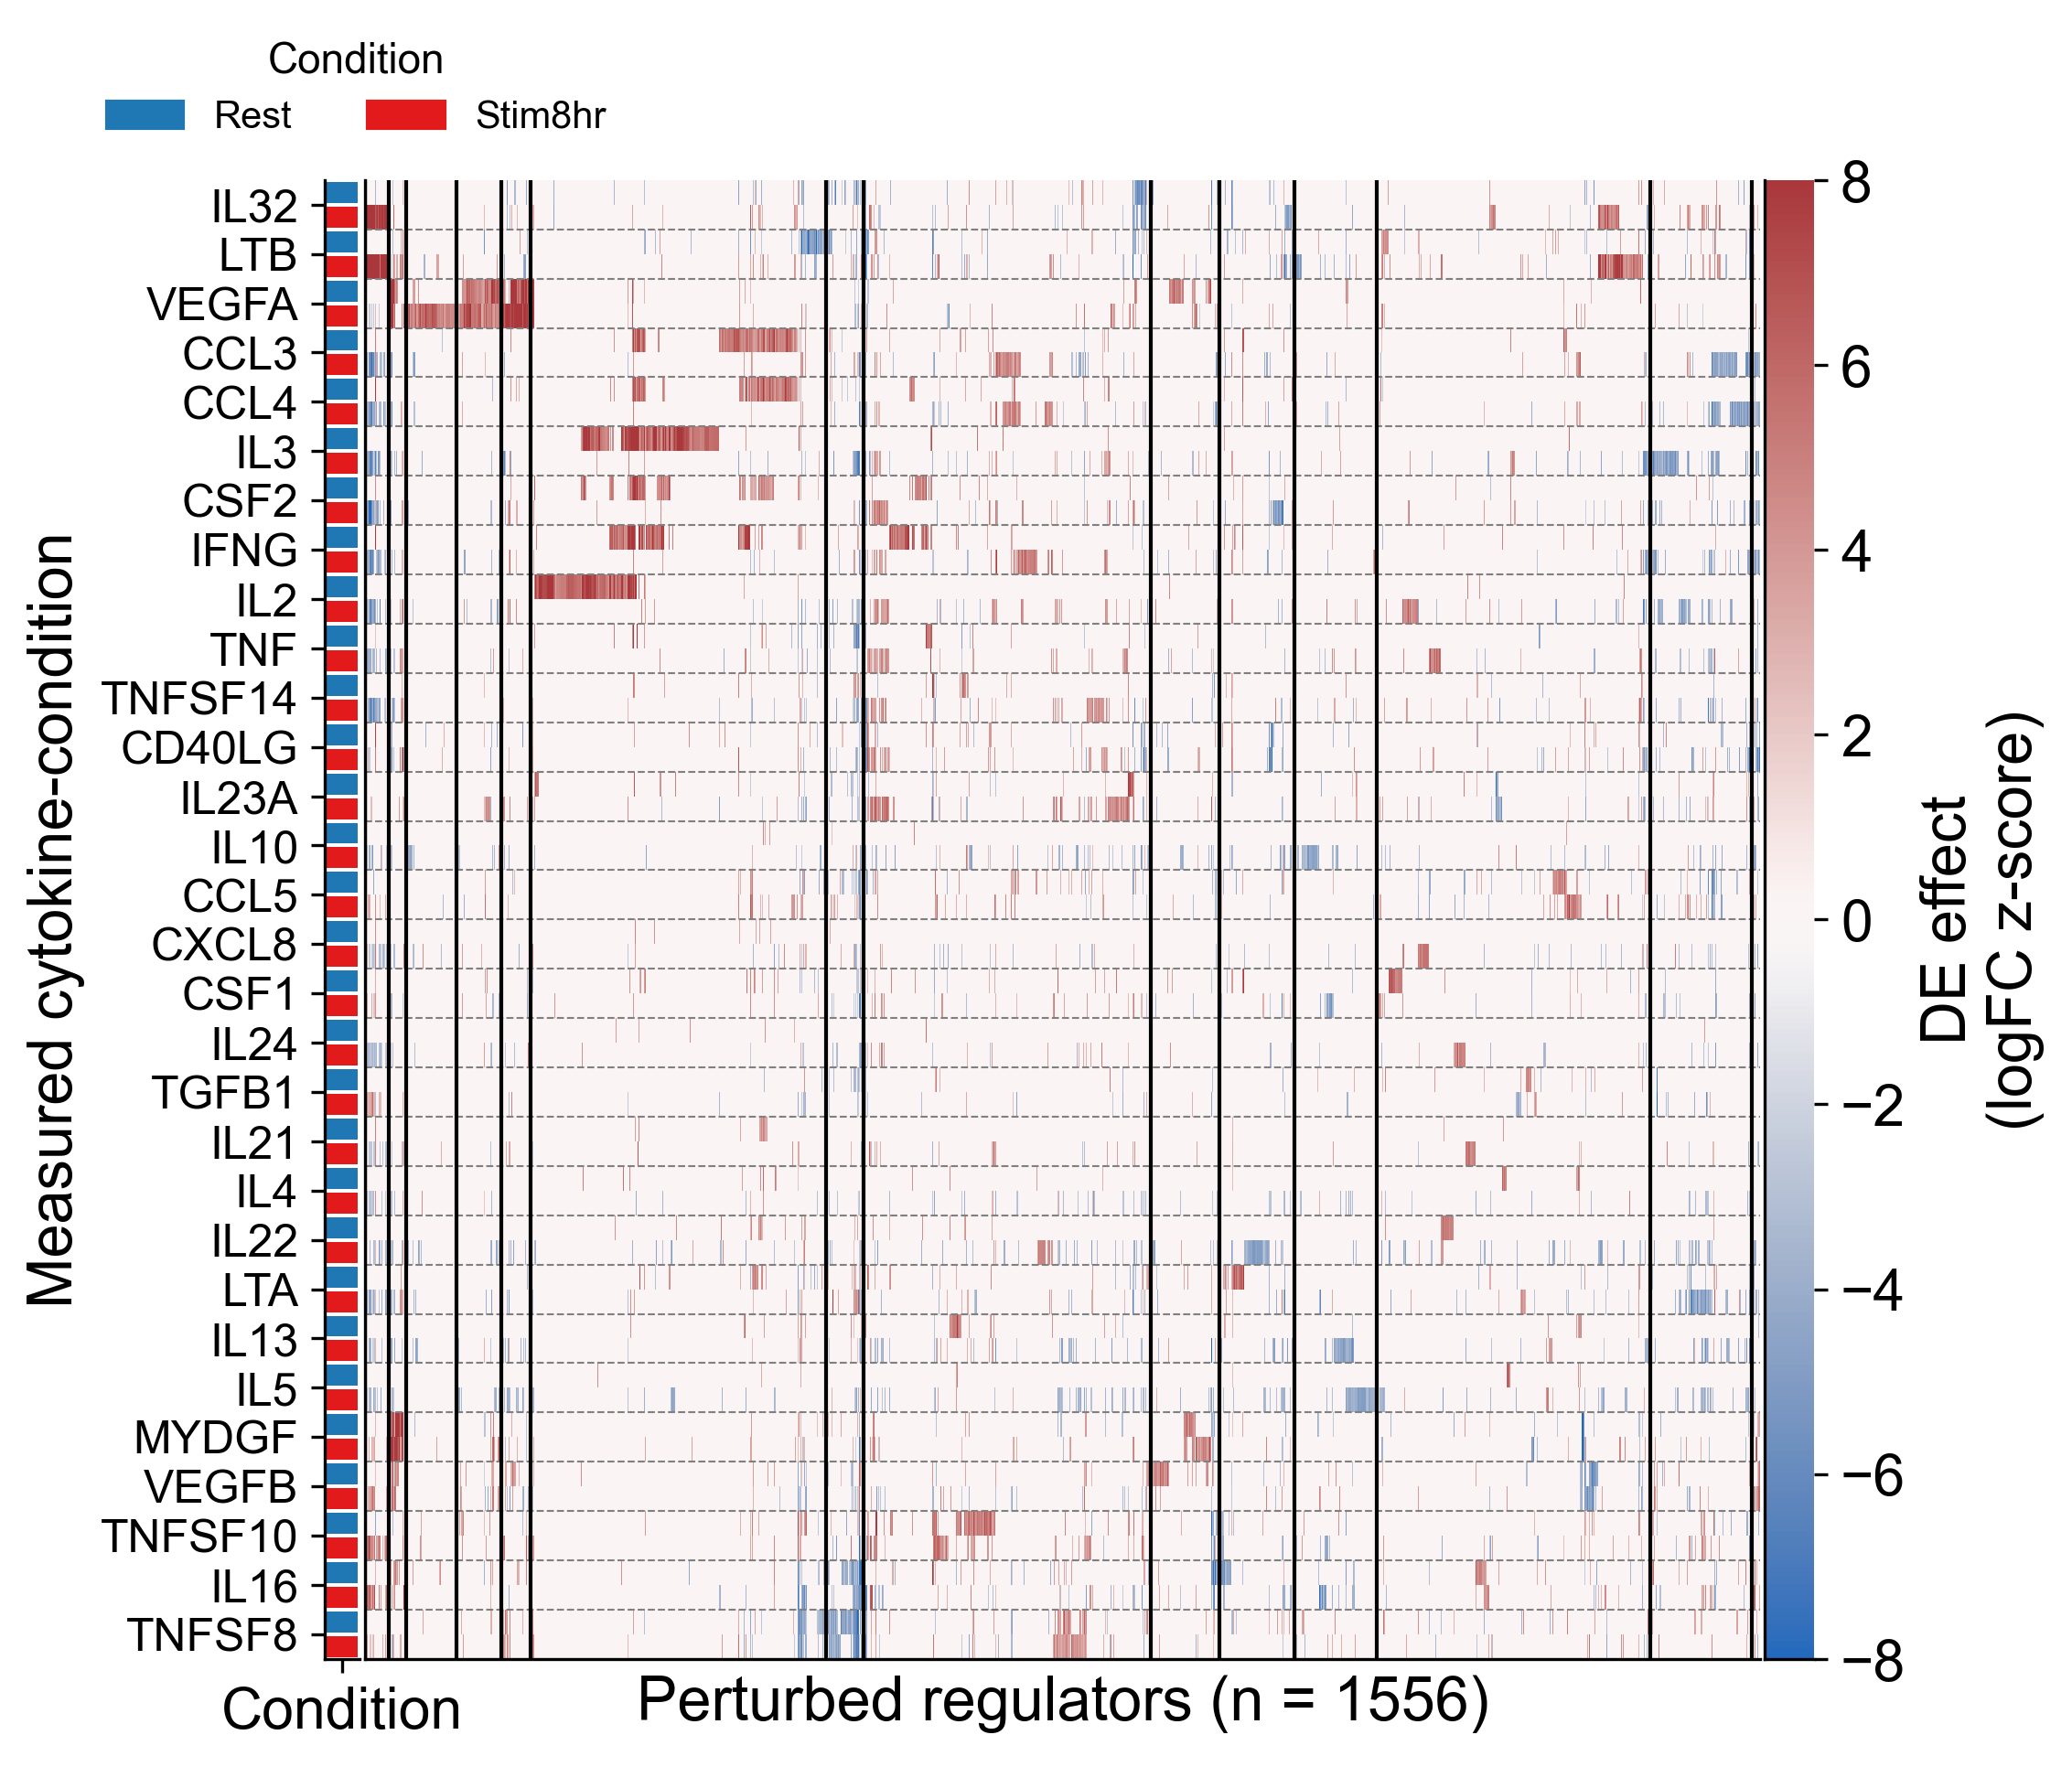

In [27]:
# Combine pivot tables vertically
rest_pl_df['condition'] = 'Rest'
stim8hr_pl_df['condition'] = 'Stim8hr'
stim48hr_pl_df['condition'] = 'Stim48hr'
combined_pl_df = pd.concat([rest_pl_df, stim8hr_pl_df, stim48hr_pl_df])
combined_pl_df = (combined_pl_df.reset_index()
    .sort_values(['gene_name', 'condition'],
                 key=lambda x: pd.Categorical(x, categories=all_genes_order + ['Rest', 'Stim8hr', 'Stim48hr'], ordered=True))
    .set_index(['gene_name', 'condition']))

plot_conditions = ['Rest', 'Stim8hr']

# Subset to Rest and Stim8hr
data_to_plot = combined_pl_df.loc[
    [(g, c) for g in all_genes_order for c in plot_conditions]
]
# Exclude regulators with no effect in conditions of interest
data_to_plot = data_to_plot.loc[:, data_to_plot.sum(0) != 0]

# Cluster columns
g = sns.clustermap(data_to_plot, row_cluster=False, method='ward')
pl_regulators_order = data_to_plot.columns[g.dendrogram_col.reordered_ind].tolist()
n_clusters = 15
col_clusters = fcluster(g.dendrogram_col.linkage, n_clusters, criterion='maxclust')[g.dendrogram_col.reordered_ind]
column_cluster_df = pd.DataFrame({'column_name': pl_regulators_order, 'cluster': col_clusters}).reset_index(drop=True)
plt.close()

# --- Plot ---
y_labelsize = 12
fig = plt.figure(figsize=(7, 7))
gs_fig = fig.add_gridspec(1, 3, width_ratios=[0.05, 2, 0.07], wspace=0.01)

# Row color annotation
ax_colors = fig.add_subplot(gs_fig[0, 0])
condition_mapping = {c: i for i, c in enumerate(plot_conditions)}
row_color_codes = [condition_mapping[c] for _ in all_genes_order for c in plot_conditions]
condition_colors = [palettes['culture_condition'][c] for c in plot_conditions]
cmap_cond = ListedColormap(condition_colors)

sns.heatmap(np.array(row_color_codes).reshape(-1, 1), cmap=cmap_cond, cbar=False,
            yticklabels=False, xticklabels=['Condition'],
            linewidths=0.5, linecolor='white', ax=ax_colors)

y_tick_locs = [i * 2 + 1 for i in range(len(all_genes_order))]
ax_colors.set_yticks(y_tick_locs)
ax_colors.set_yticklabels(all_genes_order, fontsize=y_labelsize)
ax_colors.set_ylabel('Measured cytokine-condition')

legend_patches = [mpatches.Patch(color=palettes['culture_condition'][c], label=c) for c in plot_conditions]
ax_colors.legend(handles=legend_patches, title='Condition', frameon=False, ncols=2,
                 bbox_to_anchor=(0.9, 1.02), loc='lower center', fontsize=10, title_fontsize=11, borderaxespad=0.)

# Heatmap
ax1 = fig.add_subplot(gs_fig[0, 1])
cbar_ax = fig.add_subplot(gs_fig[0, 2])

sns.heatmap(data_to_plot[pl_regulators_order], center=0, cmap=palettes['DE_effects_cmap'],
            vmax=8, vmin=-8, cbar=True, cbar_ax=cbar_ax,
            cbar_kws={'label': 'DE effect\n(logFC z-score)', 'shrink': 0.85},
            xticklabels=False, yticklabels=False, ax=ax1, rasterized=True)
ax1.set_xlabel(f'Perturbed regulators (n = {data_to_plot.shape[1]})')
ax1.set_ylabel('')

# Horizontal lines between cytokines
for i in range(1, len(all_genes_order)):
    ax1.axhline(y=i * 2, color='gray', linestyle='--', linewidth=0.5)

# Vertical lines at specified positions
vline_positions = [0, 27, 46, 102, 152, 185, 514, 556, 876, 953, 1037, 1128, 1434, 1547]
for pos in vline_positions:
    ax1.axvline(x=pos, color='black', linewidth=1)

sns.despine()
fig.tight_layout()

### Selected enrichment to be highlighted

In [14]:
highlighted_set = {
    'TCR activation': [
        'ITK', 'ZAP70', 'PTPRC', 'LCK', 'CD3G', 'LCP2', 'PLCG1', 'CD247', 'CD3E', 'CD3D', 'LAT', 'VAV1'
        ],
    'Mitochrondrial functions': [
        'MRPS17', 'GADD45GIP1', 'MRPS15', 'MRPS35', 'MRPS23', 'MARS1', 'MRPL16', 'MRPL14', 'MRPL37', 'MRPL10',
        'MRPL11', 'LARS2', 'GARS1', 'EIF2B1', 'FARSA', 'NDUFA8', 'ATP5PF', 'SLC25A3', 'MRPS15',
        'ISCA1', 'NDUFS8', 'ATP5F1B', 'AIFM1', 'SUCLG1', 'DLD', 'MRPL11', 'TIMM50'
        ],
    'Elongator': [
        'CTU2', 'CTU1', 'URM1', 'ELP1', 'ELP2', 'ELP3', 'ELP4', 'ELP5'
        ],
    'Mediator-SAGA': [
        'MED1', 'MED12', 'MED19', 'MED24', 'TADA1', 'TADA2B', 'TAF6L',
        'ENY2', 'USP22', 'SGF29', 'SUPT20H', 'SUPT7L'
        ],
 'Ragulator-Rag': [
     'FLCN', 'RRAGA', 'WDR59', 'MIOS', 'RRAGC', 'MLST8', 'LAMTOR2', 'LAMTOR4', 'LAMTOR3', 'LAMTOR5'
     ],
 'mRNA processing': [
     'RBM8A', 'DHX9', 'DHX35', 'WBP4', 'STRAP', 'PPIH', 'HNRNPR', 'RBM10'
     ],
 'Glycolysis': [
     'PKM', 'PGAM1', 'PGK1', 'ENO1', 'ALDOA', 'GAPDH'
     ]
 }

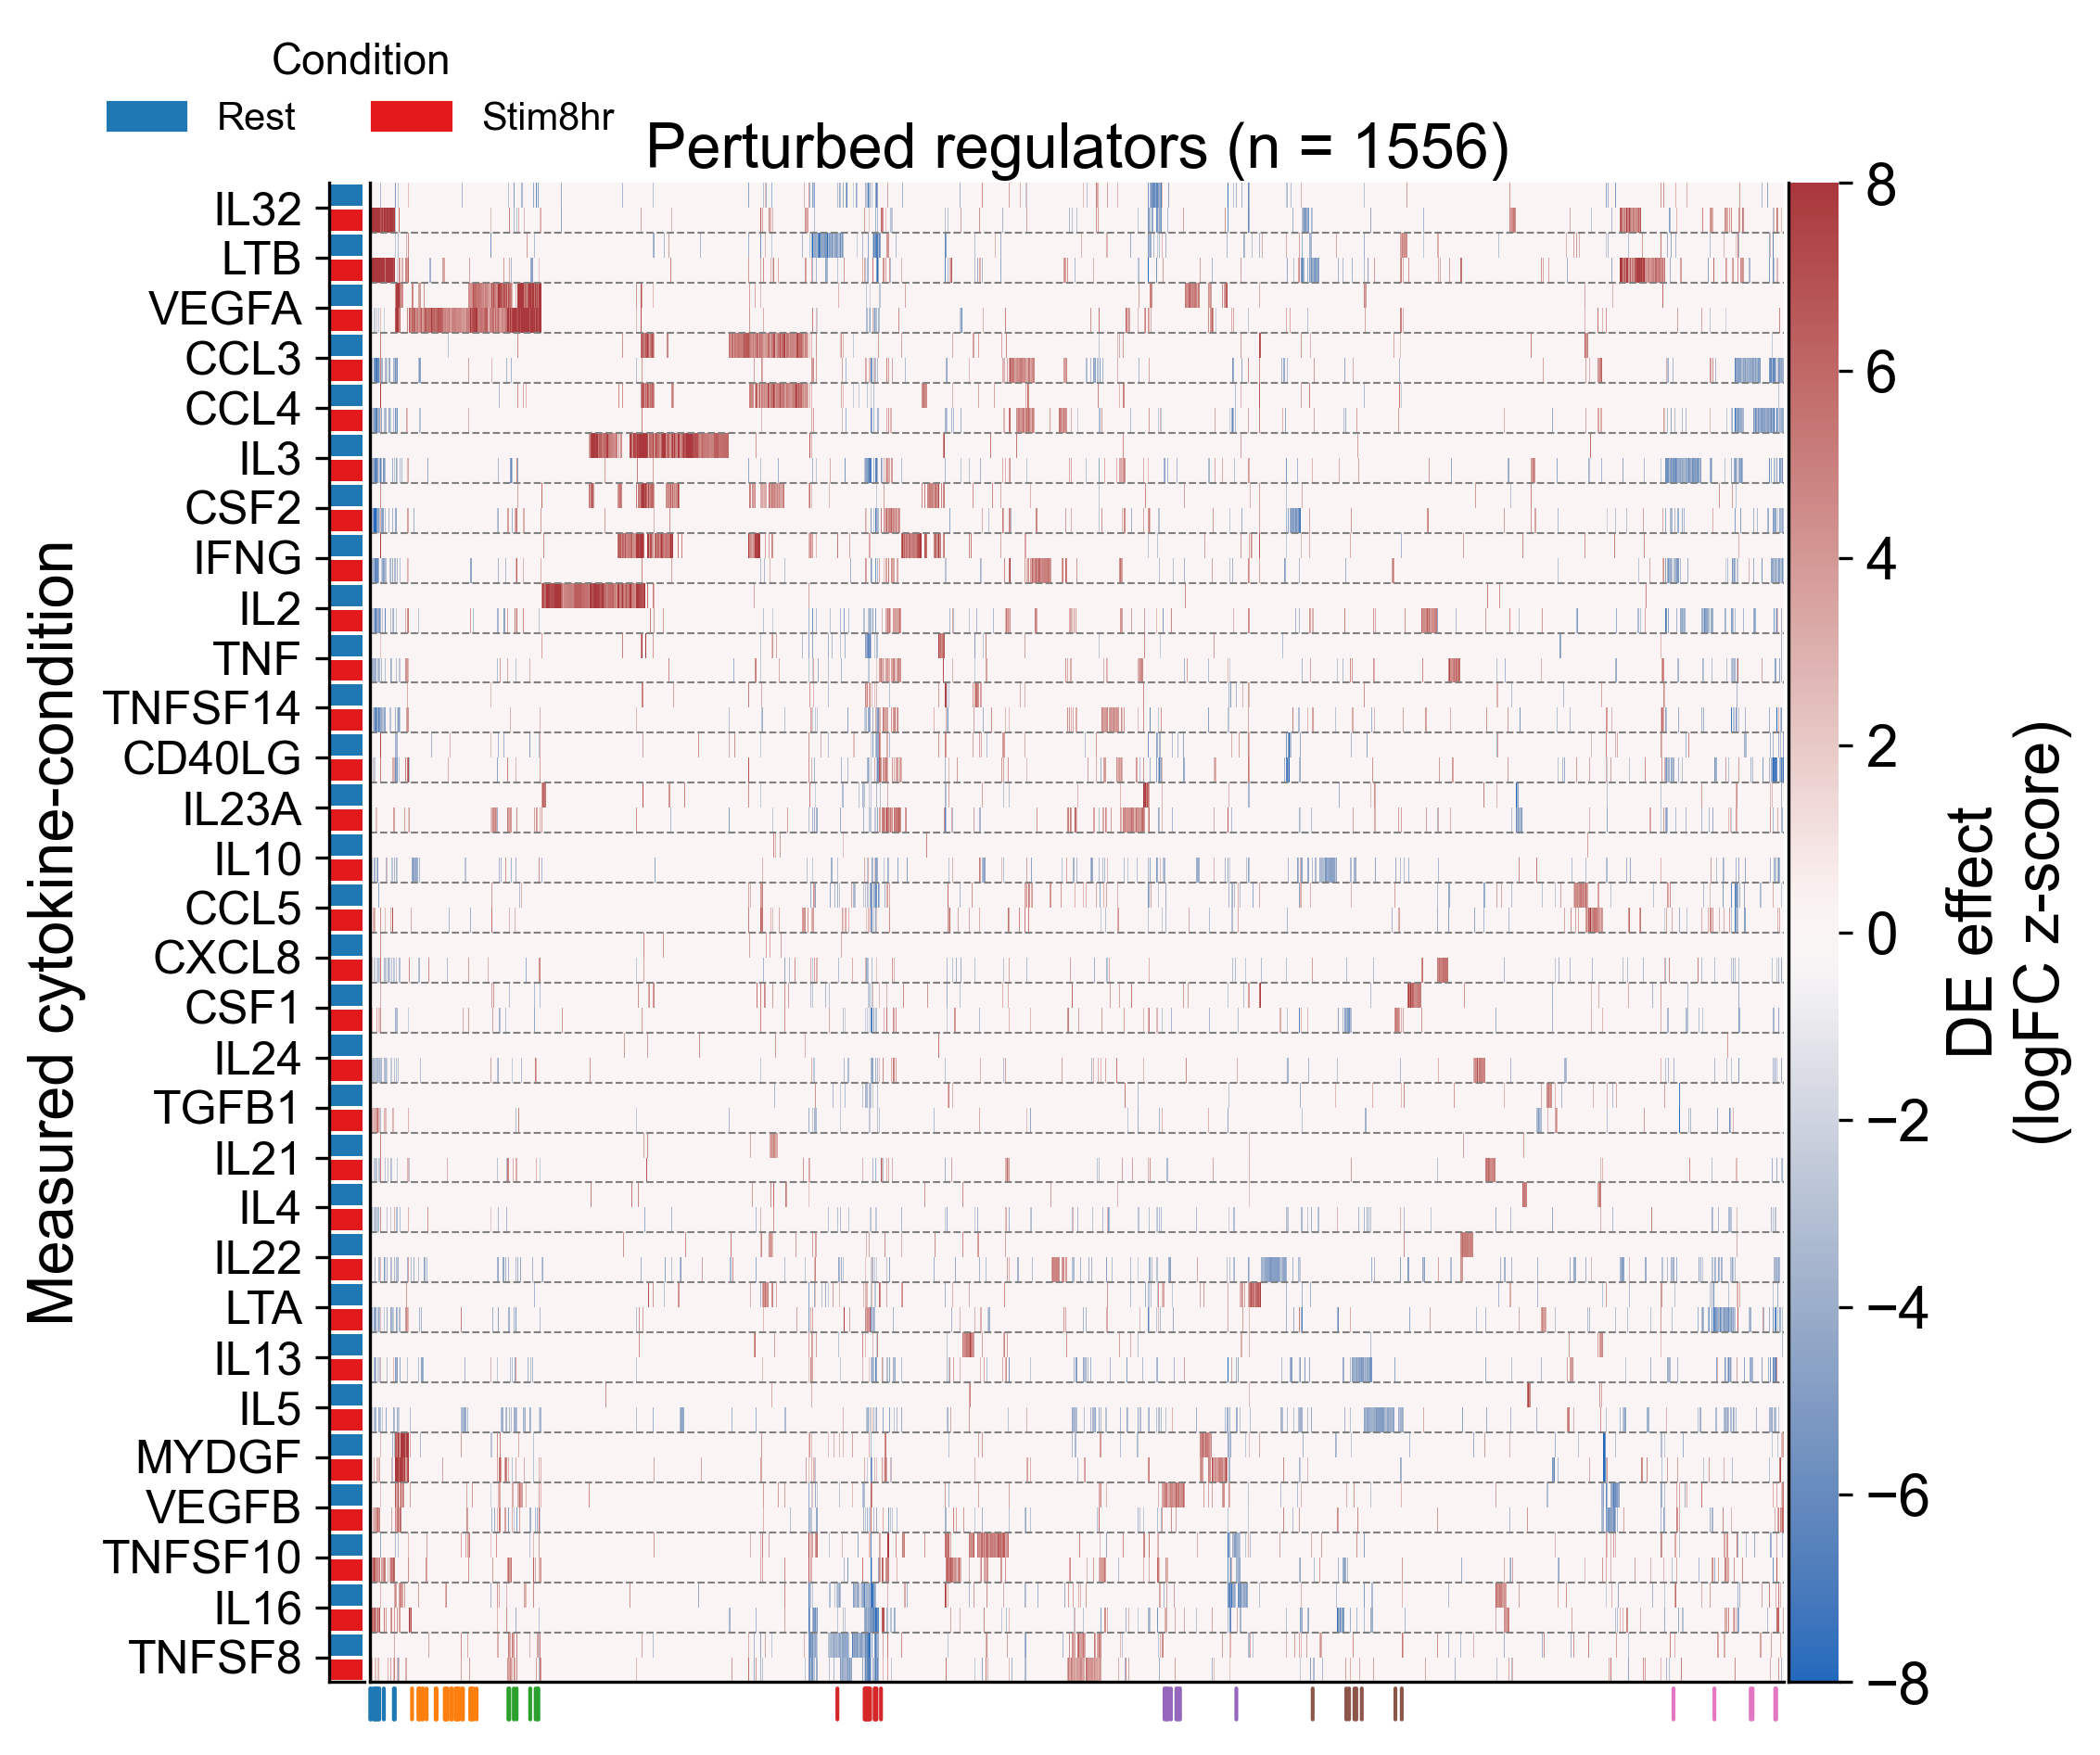

In [18]:
# Make final plots
# Combine pivot tables vertically
rest_pl_df['condition'] = 'Rest'
stim8hr_pl_df['condition'] = 'Stim8hr'
stim48hr_pl_df['condition'] = 'Stim48hr'
combined_pl_df = pd.concat([rest_pl_df, stim8hr_pl_df, stim48hr_pl_df])
combined_pl_df = (combined_pl_df.reset_index()
    .sort_values(['gene_name', 'condition'],
                 key=lambda x: pd.Categorical(x, categories=all_genes_order + ['Rest', 'Stim8hr', 'Stim48hr'], ordered=True))
    .set_index(['gene_name', 'condition']))

plot_conditions = ['Rest', 'Stim8hr']

# Subset to Rest and Stim8hr
data_to_plot = combined_pl_df.loc[
    [(g, c) for g in all_genes_order for c in plot_conditions]
]
# Exclude regulators with no effect in conditions of interest
data_to_plot = data_to_plot.loc[:, data_to_plot.sum(0) != 0]

# Cluster columns
g = sns.clustermap(data_to_plot, row_cluster=False, method='ward')
pl_regulators_order = data_to_plot.columns[g.dendrogram_col.reordered_ind].tolist()
n_clusters = 15
col_clusters = fcluster(g.dendrogram_col.linkage, n_clusters, criterion='maxclust')[g.dendrogram_col.reordered_ind]
column_cluster_df = pd.DataFrame({'column_name': pl_regulators_order, 'cluster': col_clusters}).reset_index(drop=True)
plt.close()

# --- Build highlighted gene tick positions ---
highlighted_positions = {}
for label, genes in highlighted_set.items():
    positions = [pl_regulators_order.index(g) for g in genes if g in pl_regulators_order]
    if positions:
        highlighted_positions[label] = positions

# --- Plot ---
y_labelsize = 12
fig = plt.figure(figsize=(7, 7))
gs_fig = fig.add_gridspec(1, 3, width_ratios=[0.05, 2, 0.07], wspace=0.01)

# Row color annotation
ax_colors = fig.add_subplot(gs_fig[0, 0])
condition_mapping = {c: i for i, c in enumerate(plot_conditions)}
row_color_codes = [condition_mapping[c] for _ in all_genes_order for c in plot_conditions]
condition_colors = [palettes['culture_condition'][c] for c in plot_conditions]
cmap_cond = ListedColormap(condition_colors)

sns.heatmap(np.array(row_color_codes).reshape(-1, 1), cmap=cmap_cond, cbar=False,
            yticklabels=False, xticklabels=False,
            linewidths=0.5, linecolor='white', ax=ax_colors)

y_tick_locs = [i * 2 + 1 for i in range(len(all_genes_order))]
ax_colors.set_yticks(y_tick_locs)
ax_colors.set_yticklabels(all_genes_order, fontsize=y_labelsize)
ax_colors.set_ylabel('Measured cytokine-condition')

legend_patches = [mpatches.Patch(color=palettes['culture_condition'][c], label=c) for c in plot_conditions]
ax_colors.legend(handles=legend_patches, title='Condition', frameon=False, ncols=2,
                 bbox_to_anchor=(0.9, 1.02), loc='lower center', fontsize=10, title_fontsize=11, borderaxespad=0.)

# Heatmap
ax1 = fig.add_subplot(gs_fig[0, 1])
cbar_ax = fig.add_subplot(gs_fig[0, 2])

sns.heatmap(data_to_plot[pl_regulators_order], center=0, cmap=palettes['DE_effects_cmap'],
            vmax=8, vmin=-8, cbar=True, cbar_ax=cbar_ax,
            cbar_kws={'label': 'DE effect\n(logFC z-score)', 'shrink': 0.85},
            xticklabels=False, yticklabels=False, ax=ax1, rasterized=True)

# Move x-label to top
ax1.xaxis.set_label_position('top')
ax1.set_xlabel(f'Perturbed regulators (n = {data_to_plot.shape[1]})')
ax1.set_ylabel('')

# Horizontal lines between cytokines
for i in range(1, len(all_genes_order)):
    ax1.axhline(y=i * 2, color='gray', linestyle='--', linewidth=0.5)

# Highlighted_set colored tick marks below heatmap
# Use ax.annotate in figure coords to place ticks outside the axes
colors_cycle = plt.cm.tab10.colors
n_rows = data_to_plot.shape[0]
n_cols = data_to_plot.shape[1]
for i, (label, positions) in enumerate(highlighted_positions.items()):
    color = colors_cycle[i % len(colors_cycle)]
    for pos in positions:
        # Convert data x to axes fraction, place y just below axes
        x_frac = (pos + 0.5) / n_cols
        ax1.annotate('', xy=(x_frac, 0.001), xycoords='axes fraction',
                     xytext=(x_frac, -0.03), textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='-', color=color, lw=1))

ax1.set_xticks([])

sns.despine()
fig.tight_layout()
fig.savefig('results/cytokine_regulators_overview.rest_stim8hr_annotated.pdf', bbox_inches='tight', dpi=600)
fig.savefig('results/cytokine_regulators_overview.rest_stim8hr_annotated.png', bbox_inches='tight', dpi=600)

In [13]:
# Print positions of Mitochondrial functions genes
mito_genes = highlighted_set['Mitochrondrial functions']
print("Mitochrondrial functions gene positions in pl_regulators_order:")
for g in mito_genes:
    if g in pl_regulators_order:
        pos = pl_regulators_order.index(g)
        print(f"  {g}: position {pos}")
    else:
        print(f"  {g}: not found")

Mitochrondrial functions gene positions in pl_regulators_order:
  MRPS17: position 53
  GADD45GIP1: position 82
  MRPS15: position 96
  MRPS35: position 89
  MRPS23: position 85
  MARS1: position 110
  MRPL16: position 94
  MRPL14: position 58
  MRPL37: position 101
  MRPL10: position 46
  MRPL11: position 54
  LARS2: position 102
  GARS1: position 114
  SEC61B: position 28
  EIF2B1: position 72
  FARSA: position 111
  NDUFA8: position 83
  ATP5PF: position 98
  SLC25A3: position 73
  MRPS15: position 96
  ISCA1: position 112
  NDUFS8: position 84
  ATP5F1B: position 90
  AIFM1: position 117
  SUCLG1: position 95
  DLD: position 62
  MRPL11: position 54
  TIMM50: position 57
